##### Author: Pablo Iañez Picazo 
##### Biomedical Data Science lab, ISGlobal

In [37]:
# Load all the necessary libraries

from glob import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import zscore

from statannotations.Annotator import Annotator

# Supress all warnings (bcoz they're quite annoying)
import warnings

warnings.filterwarnings("ignore")

from hsc_spatial_stats import *

In [38]:
# Set some aesthetical parameters for seaborn
sns.set(rc={'figure.figsize':(20, 16)})
sns.set_style("whitegrid")

In [39]:
# ------------------------ Set up some parameters --------------------------- #
# Image resolution after resizing, which is 5 micrometers per pixel
res = 0.1
# cluster forming threshold - threshold at which intensities above this value
# will be considered belonging to a DAPI-Intense Region (DIR)
# Intensities to 0.6 are the one in the quantile 0.80 in young, old and treated
cft = 0.6
normalization = "z_score"
folder = "data"
conditions = [
    "young",
    "old",
    "treated_RhoAi",
    "compressed_8um",
    "compressed_5um",
    "compressed_3um",
]

properties_slide = [
    "area",
    "bbox",
    "centroid",
    "eccentricity",
    "major_axis_length",
    "minor_axis_length",
    "perimeter",
    "perimeter_crofton",
    "equivalent_diameter",
    "feret_diameter_max",
]

palette = {
    "Young": (0.00392, 0.45098, 0.69803),
    "Aged": (0.00784, 0.61960, 0.45098),
    "Aged + Ri": (0.8, 0.47058, 0.73725),
    "8μm": (0.79215, 0.56862, 0.38039),
    "5μm": (0.87058, 0.56078, 0.01960),
    "3μm": (0.83529, 0.36862, 0.0),
}

In [40]:
nuc_df = pd.read_csv(
    f"results/ZSCORENORM_nuclei_3d_res{res}_cf{cft}_df.csv", index_col=0
)
nuc_df = fix_labels(nuc_df)

23


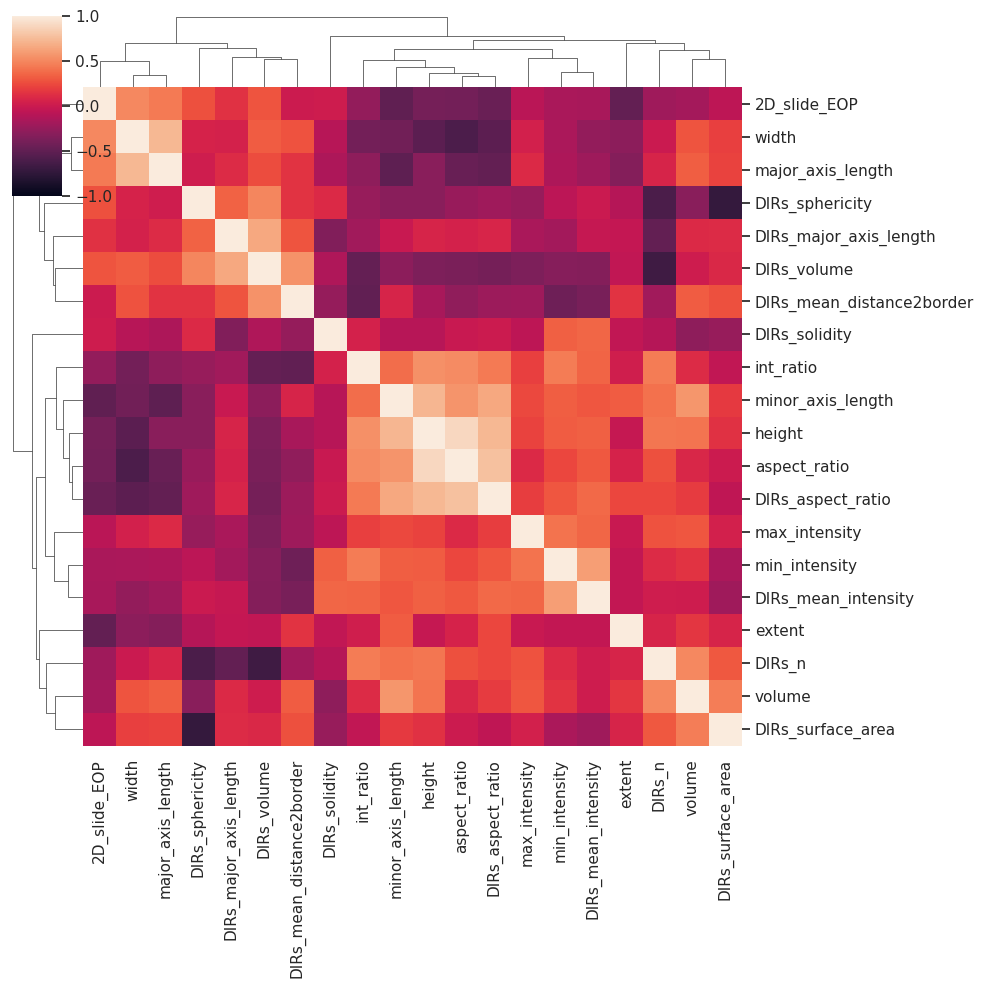

In [41]:
features = [
    "volume",
    "extent",
    "width",
    "height",
    "aspect_ratio",
    "major_axis_length",
    "minor_axis_length",
    "min_intensity",
    "max_intensity",
    "DIRs_volume",
    "DIRs_aspect_ratio",
    "DIRs_surface_area",
    "DIRs_major_axis_length",
    "DIRs_sphericity",
    "DIRs_mean_intensity",
    "DIRs_solidity",
    "DIRs_mean_distance2border",
    "DIRs_n",
    "2D_slide_EOP",
    "int_ratio",
    "condition",
    "im_path",
    "im_batch",
]

print(len(features))

my_df = nuc_df[features]
int_df = nuc_df[features[:-3]]
norm_df = int_df.apply(zscore)

sns.clustermap(norm_df.corr(), dendrogram_ratio=0.1, vmin=-1, vmax=1)

In [42]:
my_df.condition.value_counts()

Young         176
Aged          146
Aged + Ri     126
RhoA KO        79
Aged + NaB     50
5μm            25
3μm            21
8μm            16
Name: condition, dtype: int64

In [43]:
old_treated_df = my_df[my_df["condition"].isin(["Aged", "Aged + Ri"])]
old_treated_df = old_treated_df.reset_index(drop=True)

young_df = my_df[my_df["condition"] == "Young"]
conf_df = my_df[my_df["condition"].isin(["8μm", "5μm", "3μm"])]

young_conf_df = pd.concat(
    [conf_df, young_df.groupby("condition").sample(30, random_state=2023)]
)
young_conf_df = young_conf_df.reset_index(drop=True)
young_conf_df.condition.value_counts()

my_df = pd.concat([young_conf_df, old_treated_df], axis=0)
my_df = my_df.reset_index(drop=True)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA is affected by scale, first we need to standardize
# Separating out the features
x_a = young_conf_df[features[:-3]].values
x_b = old_treated_df[features[:-3]].values

transformer = StandardScaler()
x_a = transformer.fit_transform(x_a)
x_b = transformer.transform(x_b)
x = np.concatenate((x_a, x_b), axis=0)

pca_model = PCA(n_components=10)
pcs_a = pca_model.fit_transform(x_a)
pcs_b = pca_model.transform(x_b)
pcs = np.concatenate((pcs_a, pcs_b), axis=0)

pca_df = pd.DataFrame(data=pcs[:, :4], columns=["PC1", "PC2", "PC3", "PC4"])
pca_df = pd.concat([pca_df, my_df["condition"]], axis=1)
pca_df = pca_df.dropna()
pca_model.explained_variance_ratio_

array([0.39693404, 0.19048963, 0.12602587, 0.07317135, 0.04768934,
       0.03949138, 0.02938605, 0.02024478, 0.01741379, 0.01344804])

In [45]:
print(np.sum(pca_model.explained_variance_ratio_[:4]))
print(np.sum(pca_model.explained_variance_ratio_[:5]))

0.7866208942922553
0.834310236921964


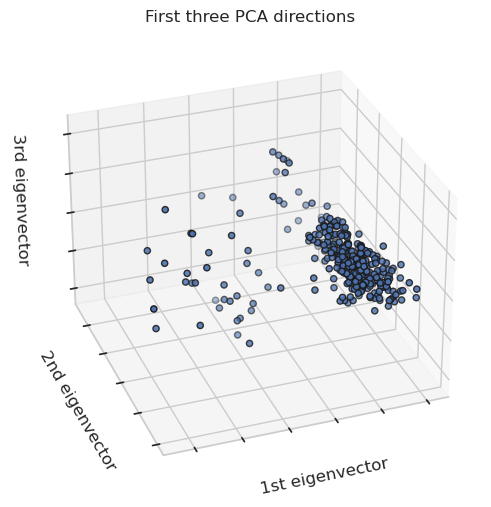

In [46]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2], cmap=plt.cm.Set1, edgecolor="k")

ax.set_title("First three PCA directions")
ax.set_xlabel("1st eigenvector")
ax.w_xaxis.set_ticklabels([])
ax.set_ylabel("2nd eigenvector")
ax.w_yaxis.set_ticklabels([])
ax.set_zlabel("3rd eigenvector")
ax.w_zaxis.set_ticklabels([])

plt.show()

In [47]:
expl_ratio = pca_model.explained_variance_ratio_
expl_ratio*100

array([39.69340432, 19.04896332, 12.60258667,  7.31713512,  4.76893426,
        3.94913795,  2.93860481,  2.02447771,  1.7413788 ,  1.34480406])

Text(0, 0.5, 'Cumulative Explained Variance (%)')

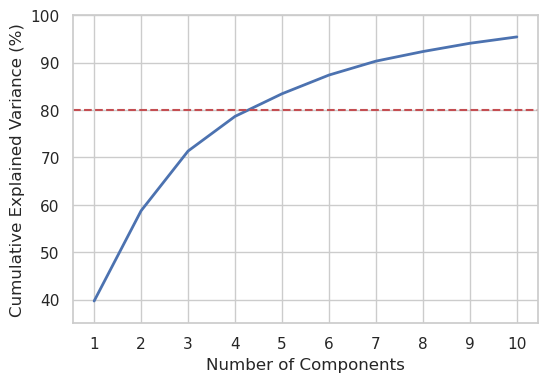

In [48]:
plt.figure(figsize=(6, 4))
# Poner el porcentaje en 100% y una tabla de feature loading al lado en supporting information
# Hacer un barplot de los top 5 - 6 - 8 feature loadings los que entren bien al lado

cum_var = np.cumsum(expl_ratio)

plt.plot(cum_var * 100, linewidth=2)
plt.axhline(y=80, color="r", linestyle="--")

# Make the x ticks start at 1
plt.xticks(np.arange(len(expl_ratio)), np.arange(1, len(expl_ratio) + 1))

plt.ylim((35, 100))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")

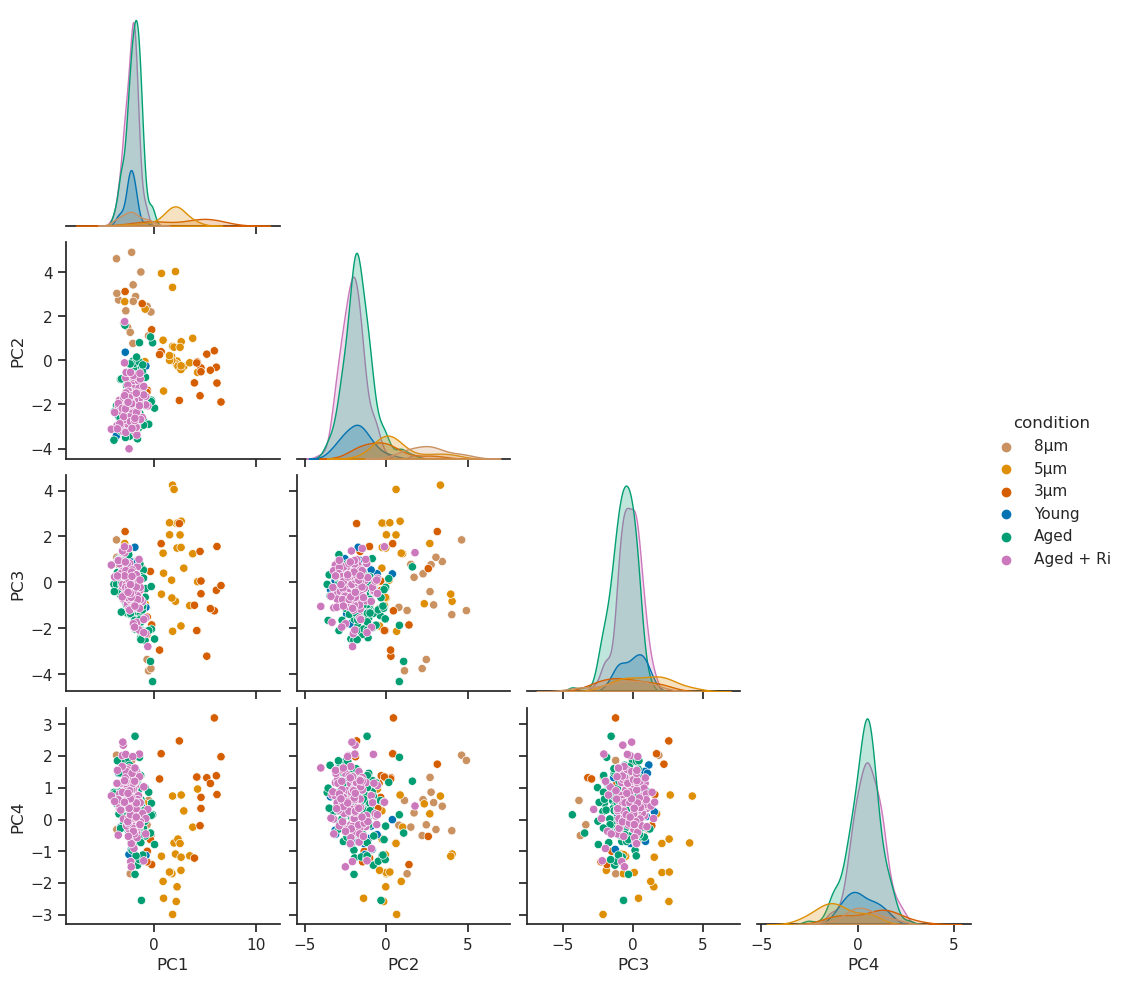

In [49]:
sns.set_style("ticks")
sns.pairplot(pca_df, hue="condition", corner = True, palette=palette)

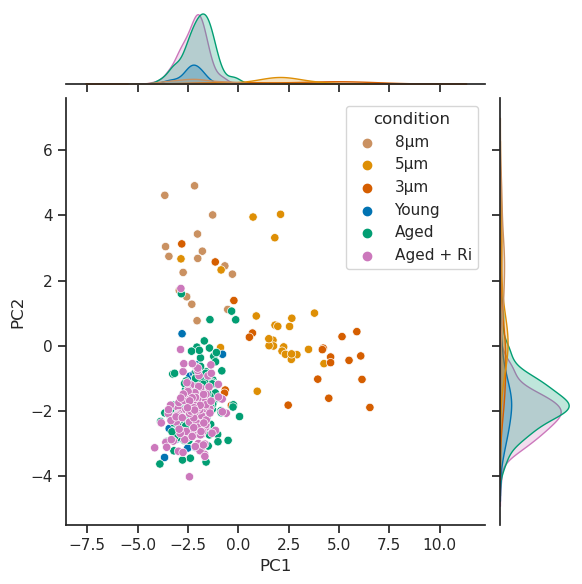

In [50]:
sns.jointplot(data=pca_df, x="PC1", y="PC2", hue="condition", palette=palette)

In [51]:
# get the index of the most important feature on EACH component
most_important_feats = [
    features[:-3][np.abs(pc).argmax()] for pc in pca_model.components_
]

# Build the dataframe
# Check the most contributing feature for each of the pcs
n_pcs = pca_model.components_.shape[0]
dic = {f"PC{i+1}": most_important_feats[i] for i in range(n_pcs)}
importance_df = pd.DataFrame(dic.items())
importance_df = importance_df.T
importance_df

,0,1,2,3,4,5,6,7,8,9
0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1,DIRs_aspect_ratio,DIRs_mean_distance2border,major_axis_length,extent,min_intensity,max_intensity,volume,min_intensity,2D_slide_EOP,extent


In [52]:
print(pca_model.components_.shape)

# Create a dataframe for the first 5 components that explain more than the 80% 
# of the variance
loadings_df = pd.DataFrame(np.abs(pca_model.components_[:5]))
mapper = {list(loadings_df.columns)[i]: f for i, f in enumerate(features[:-3])}
loadings_df = loadings_df.rename(columns=mapper)
loadings_df = loadings_df.multiply(pca_model.explained_variance_ratio_[:5], axis=0)
loadings_df

(10, 20)


,volume,extent,width,height,aspect_ratio,major_axis_length,minor_axis_length,min_intensity,max_intensity,DIRs_volume,DIRs_aspect_ratio,DIRs_surface_area,DIRs_major_axis_length,DIRs_sphericity,DIRs_mean_intensity,DIRs_solidity,DIRs_mean_distance2border,DIRs_n,2D_slide_EOP,int_ratio
0,0.069675,0.077031,0.103769,0.128810,0.125402,0.095882,0.127903,0.020174,0.041078,0.077064,0.130527,0.046663,0.041297,0.098440,0.045815,0.060098,0.017420,0.095513,0.096788,0.122397
1,0.058739,0.025431,0.015760,0.009852,0.007534,0.017047,0.020420,0.061528,0.030842,0.052641,0.006210,0.054061,0.051485,0.000216,0.074752,0.065626,0.087225,0.006147,0.009230,0.018273
2,0.036836,0.002183,0.044271,0.011115,0.022181,0.048367,0.013600,0.004301,0.030799,0.033908,0.014175,0.035339,0.035382,0.044043,0.002038,0.004542,0.014092,0.047976,0.000435,0.011730
3,0.011507,0.037299,0.009464,0.016589,0.010236,0.006032,0.010917,0.018555,0.025026,0.012337,0.006568,0.011190,0.029122,0.003917,0.019525,0.006089,0.002727,0.004582,0.024568,0.000652
4,0.002732,0.011314,0.001634,0.005501,0.006073,0.002168,0.001069,0.024535,0.003702,0.014493,0.006449,0.017002,0.004935,0.007953,0.005193,0.015166,0.006319,0.011677,0.019622,0.000930


In [53]:
loadings_df.sum(axis=0).sort_values(ascending=False)

DIRs_volume                  0.190443
volume                       0.179489
width                        0.174897
minor_axis_length            0.173909
height                       0.171868
aspect_ratio                 0.171427
major_axis_length            0.169497
DIRs_n                       0.165895
DIRs_surface_area            0.164255
DIRs_aspect_ratio            0.163930
DIRs_major_axis_length       0.162220
DIRs_sphericity              0.154570
int_ratio                    0.153982
extent                       0.153258
DIRs_solidity                0.151520
2D_slide_EOP                 0.150643
DIRs_mean_intensity          0.147322
max_intensity                0.131447
min_intensity                0.129092
DIRs_mean_distance2border    0.127782
dtype: float64

<AxesSubplot:>

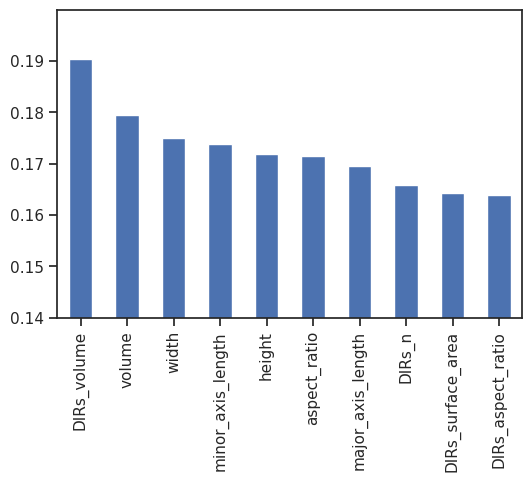

In [54]:
fig = plt.figure(1, figsize=(6, 4))
p = loadings_df.sum(axis=0).sort_values(ascending=False).head(10)
p.plot.bar(ylim=(0.14, None))

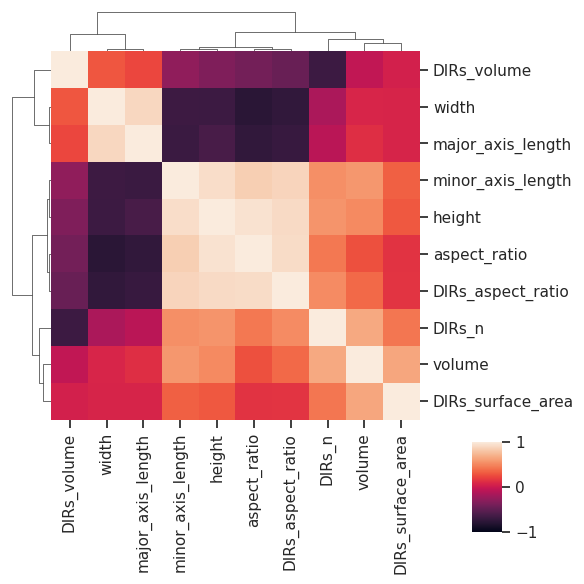

In [55]:
corr_young_conf_df = young_conf_df[p.index]
corr_young_conf_df = corr_young_conf_df.apply(zscore)

sns.clustermap(
    corr_young_conf_df.corr(),
    dendrogram_ratio=0.1,
    vmin=-1,
    figsize=(6, 6),
    vmax=1,
    cbar_pos=(0.8, 0.1, 0.05, 0.15),
)

<AxesSubplot:xlabel='DIRs_volume', ylabel='volume'>

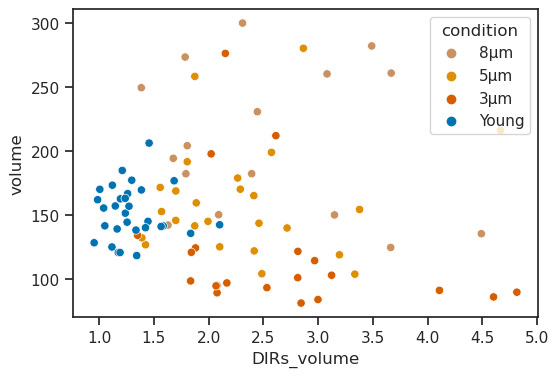

In [56]:
fig = plt.figure(1, figsize=(6, 4))
sns.scatterplot(
    data=young_conf_df, x="DIRs_volume", y="volume", 
    hue="condition", palette=palette
)

<AxesSubplot:xlabel='DIRs_n', ylabel='major_axis_length'>

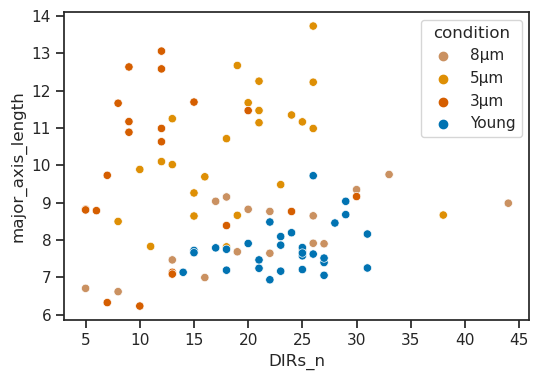

In [57]:
fig = plt.figure(1, figsize=(6, 4))
sns.scatterplot(data=young_conf_df, x="DIRs_n", 
                y="major_axis_length", hue="condition", palette=palette)